In [1]:
#importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", lambda x: "%.3f" %x) #to restrict any float number to 3dp

In [2]:
#accessing my file from my google drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


An outlier is a data point that are abnormally  or unrealistically distant from other points in the data

The challenge with outlier detection is determining if a point is truly a problem or simply a large value. If a point is genuine then it is very important to keep it in the data as otherwise we're removing the most intersting data points

It is left to the best judgement of the investigator to decide whether treating outliers is neccessary and how to go about it. Domain knowledge and impact of the business problem tend to drive the decision

**Handling Outliers**

Some of the common techniques are:
Replacement with null values: The outliers can be considered as missing data and be replaced with NaNs

IQR technique: Replacing the data points with lower whisker (Q1-1.5*1QR) or upper whisker (Q3+1.5*IQR) value.

We can also drop these observations, although might result in losing other relevant observations

Hence, it is a good idea to look at the results via running an analysis with and withiut the outliers


In [3]:
#the dataset
data=pd.read_csv("/content/drive/MyDrive/Week 1  Foundations Python and Statistics/Melbourne_HousingNomissing.csv")
data.head()

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,Regionname,Propertycount,Price
0,Airport West,3,t,Nelson,03-09-2016,13.500,3042.000,3,3,1,303.000,Western Metropolitan,3464,840000
1,Albert Park,2,h,hockingstuart,03-09-2016,3.300,3206.000,2,2,0,120.000,Southern Metropolitan,3280,1275000
2,Albert Park,2,h,Thomson,03-09-2016,3.300,3206.000,2,2,0,159.000,Southern Metropolitan,3280,1455000
3,Alphington,4,h,Brace,03-09-2016,6.400,3078.000,3,3,4,853.000,Northern Metropolitan,2211,2000000
4,Alphington,3,h,Jellis,03-09-2016,6.400,3078.000,3,3,2,208.000,Northern Metropolitan,2211,1110000


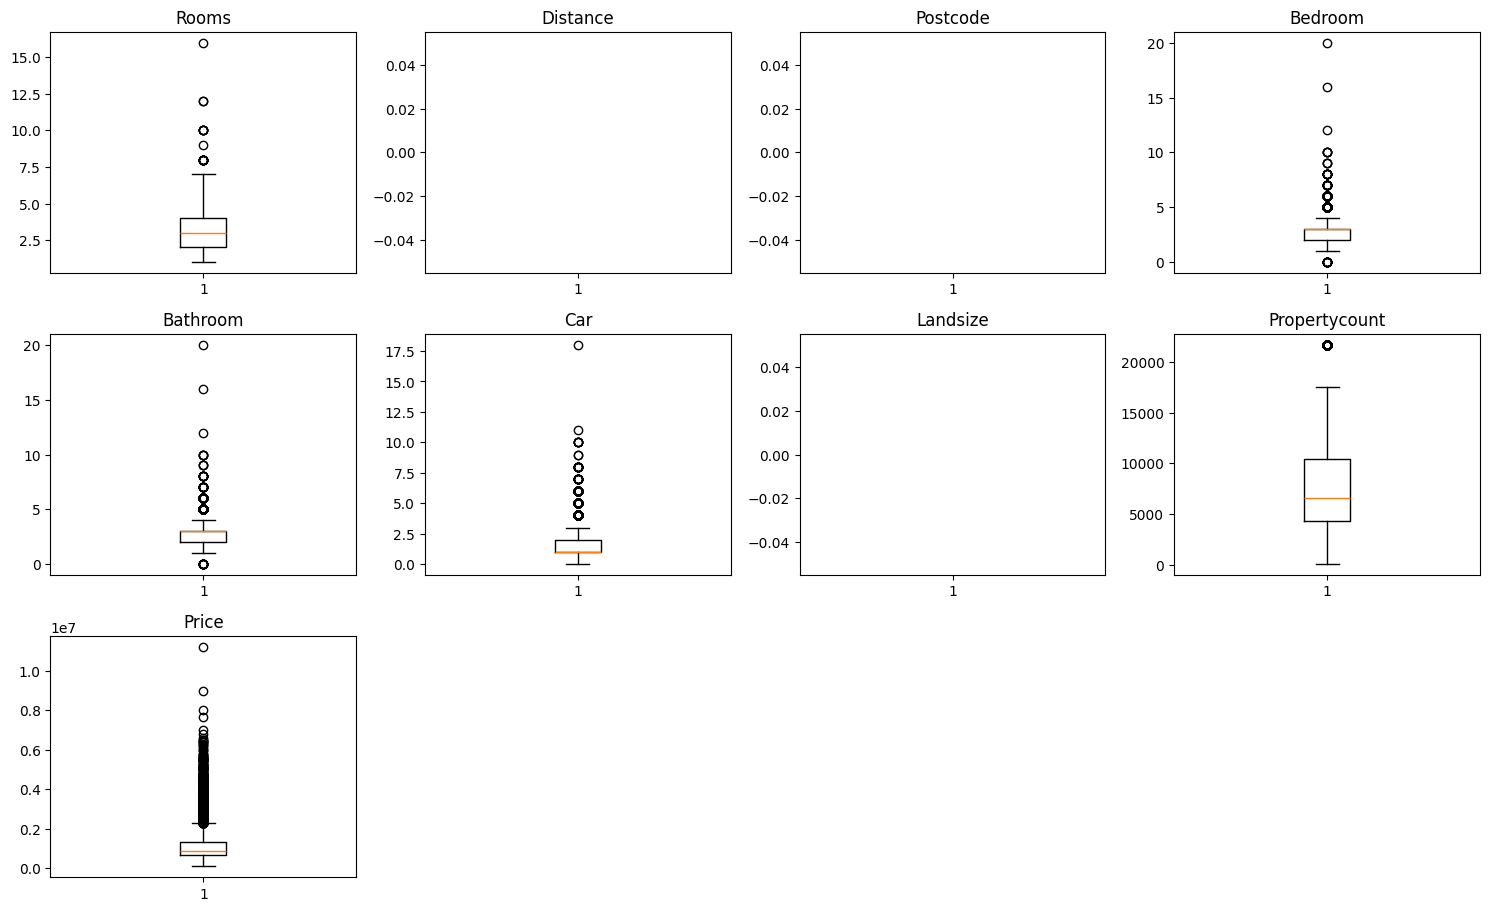

In [4]:
#visualizing the outliers
numeric_columns=[
    "Rooms",
    "Distance",
    "Postcode",
    "Bedroom",
    "Bathroom",
    "Car",
    "Landsize",
    "Propertycount",
    "Price",
]
plt.figure(figsize=(15,12))

for i, variable in enumerate(numeric_columns):
  plt.subplot(4,4,i+1)
  plt.boxplot(data[variable], whis=1.5)
  plt.tight_layout()
  plt.title(variable)

plt.show()


Obviously, there are outliers

There are three types of outliers they are:

Pount Outliers

Contextual Outliers

Collective Outliers



Finding percentage of the outliers in each column of the data with the use of IQR

In [5]:
#Finding the 25th and 75th percentile for the numerical columns
Q1=data[numeric_columns].quantile(0.25)
Q3=data[numeric_columns].quantile(0.75)

IQR=Q3-Q1 #IQR means Inter Quantile Range (75th percentile -25th percentile)

lower_whisker=(
    Q1-1.5*IQR
) #Finding the lower and upper boundsfor  all values. All values outside these bounds are outliers
upper_whisker=Q3+1.5*IQR

In [6]:
(data[numeric_columns]<lower_whisker)

,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,Propertycount,Price
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
27108,False,False,False,False,False,False,False,False,False
27109,False,False,False,False,False,False,False,False,False
27110,False,False,False,False,False,False,False,False,False
27111,False,False,False,False,False,False,False,False,False


In [7]:
#Percentage of outliers in each column
(
    (data[numeric_columns]<lower_whisker)|(data[numeric_columns]>upper_whisker)
).sum()/data.shape[0]*100

,0
Rooms,0.085
Distance,4.341
Postcode,2.910
Bedroom,4.194
Bathroom,4.194
Car,4.304
Landsize,1.652
Propertycount,2.670
Price,4.658


**Treating Outliers**

The minimum and maximum value of these columns are capped/clipped to the lower and upper whisker value of the boxplot found using Q1-1.5IQR and Q3+1.5*IQR, respectively.

**Note**
Typically, a value of 1.5*IQR is taken to cap the values of outliers to upper and lower whiskers but any number (example 0.5,2,3, etc) other than 1.5 can be chosen. The value depends upon the business problem statement

**A typical function to floor and cap/clip outliers in a column**

There are usualy three causes for outliers

(1) Data entry or measurement errors
(2) Sampling problems
(3) Unusual condiriions and Natural Variation

In [8]:
def treat_outliers(df, col):
  """
  treats outliers in a variable in a variable
  col: str, name of the numerical variable
  df: dataframe
  col:name of the column
  """

  Q1=df[col].quantile(0.25) #25th quantile
  Q3=df[col].quantile(0.75) #75th quantile
  IQR=Q3-Q1 #IQR: Inter Quantile Rnage (75th percentile - 25th percentile)
  lower_whisker=Q1-1.5*IQR
  upper_whisker=Q3+1.5*IQR

  df[col]=np.clip(df[col], lower_whisker, upper_whisker)

  return df



How to treat outliers in rooms column

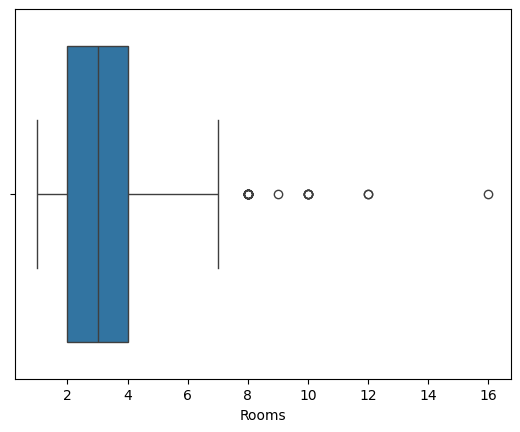

In [9]:
#Looking at the column after the treatment og the outlier
sns.boxplot(data=data, x="Rooms")
plt.show()

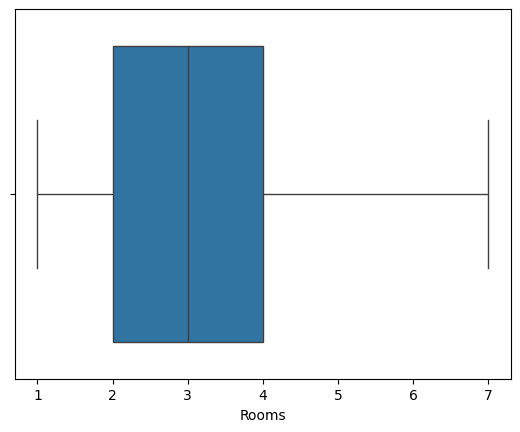

In [10]:
data=treat_outliers(data, "Rooms")

#to visualize the column
sns.boxplot(data=data, x="Rooms")
plt.show()


From the plot, the max no of rooms in a property is 7
The value 7 is the whisker value and all values greater haave been treated

---



Treating the outliers in other columns using the same approach

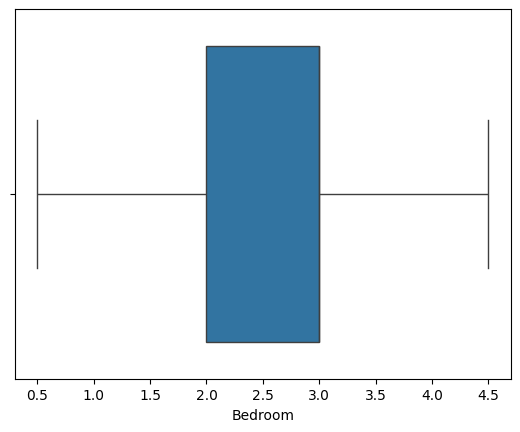

In [11]:
# Outliers of bedroom column
data=treat_outliers(data, "Bedroom")

#to visualize the column
sns.boxplot(data=data, x="Bedroom")
plt.show()

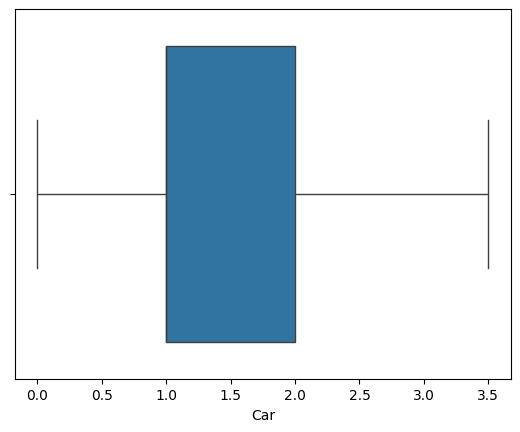

In [12]:
# Outliers of car column
data=treat_outliers(data, "Car")

sns.boxplot(data=data, x="Car")
plt.show()

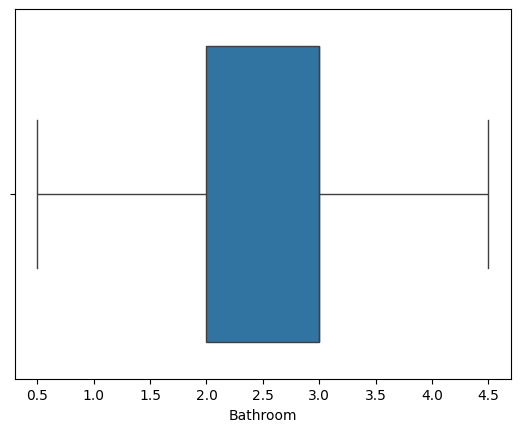

In [13]:
#Outliers of Bathroom column
data=treat_outliers(data, "Bathroom")

sns.boxplot(data=data, x="Bathroom")
plt.show()

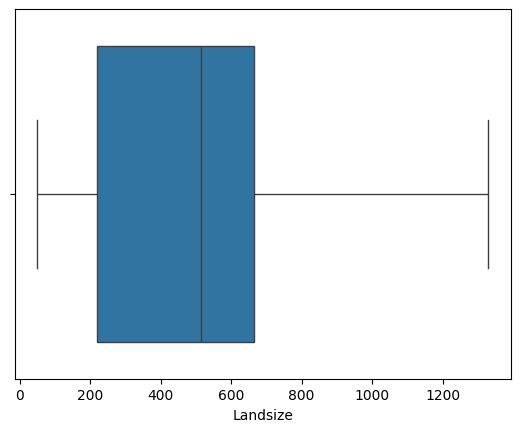

In [14]:
#Outliers of Landsize column
data=treat_outliers(data, "Landsize")

sns.boxplot(data=data, x="Landsize")
plt.show()

Numerical columns where outliers were tested

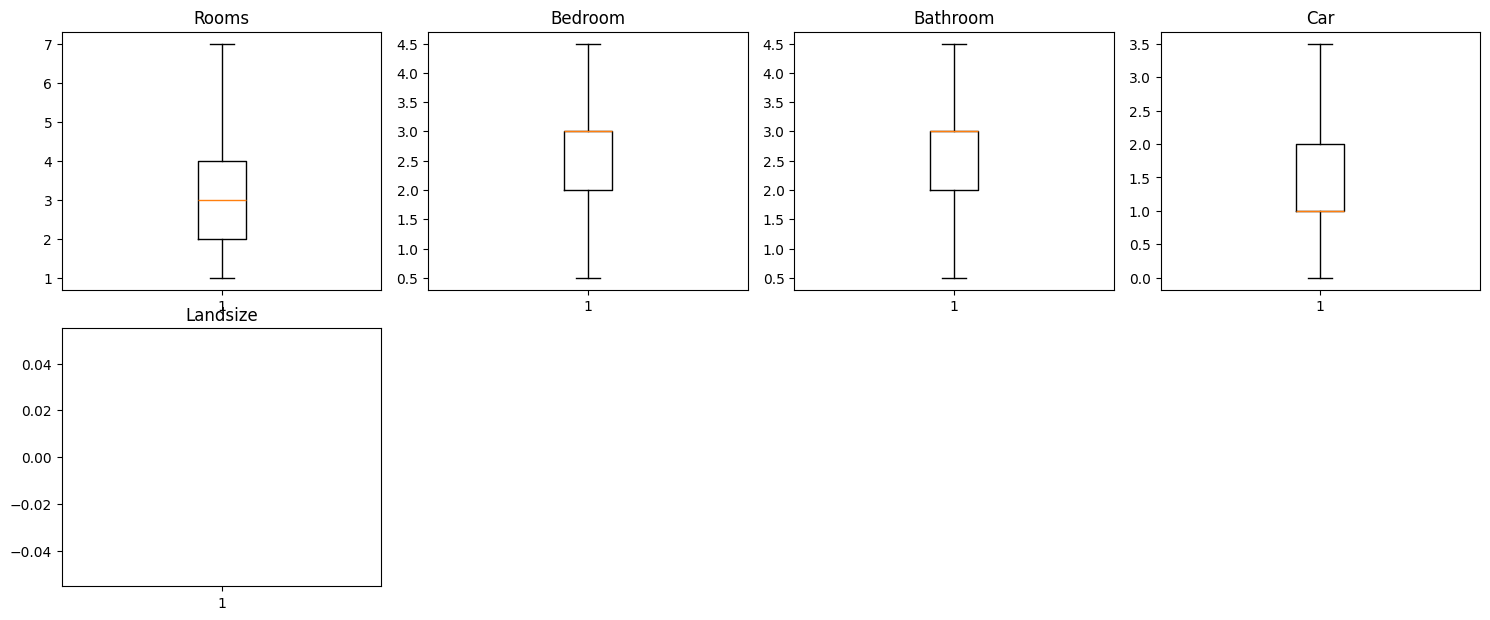

In [15]:
# detect outliers using boxplot
# selection of the numerical columns where the outliers were being treated
numeric_columns=["Rooms", "Bedroom", "Bathroom", "Car", "Landsize"]
plt.figure(figsize=(15,12))

for i, variable in enumerate(numeric_columns):
  plt.subplot(4,4,i+1)
  plt.boxplot(data[variable], whis=1.5)
  plt.tight_layout()
  plt.title(variable)
plt.show()

Coverting the floating data type to integer for Car, Bathroom, and Bedroom columns

In [16]:
data["Car"]=data["Car"].astype(int)
data["Bathroom"]=data["Bathroom"].astype(int)
data["Bedroom"]=data["Bedroom"].astype(int)

Save the data-set with all the outlier values that are treated

In [17]:
data.to_csv("/content/drive/MyDrive/Week 1  Foundations Python and Statistics/Melbourne_Housing_Without_Outliers.csv", index=False)